# Mental Health Text Classification Using NLP

#I.Introduction
La santé mentale constitue un enjeu important, et les plateformes numériques génèrent aujourd’hui une grande quantité de contenus exprimant des émotions, des expériences et des difficultés psychologiques. Le Natural Language Processing (NLP) permet d’exploiter automatiquement ces données textuelles afin d’identifier des tendances et de classifier les contenus selon différentes catégories.
Dans ce projet, nous utilisons des techniques de NLP et de Machine Learning pour analyser des textes liés à la santé mentale et prédire leur catégorie à partir de leur contenu.

#II.Problématique
Comment utiliser les techniques de NLP et de Machine Learning pour classifier automatiquement des textes liés à la santé mentale de manière fiable et pertinente ?
Le projet cherche notamment à déterminer :
- comment prétraiter efficacement les textes ?
- quelles représentations textuelles utiliser ?
- quel modèle de classification est le plus adapté?
- comment évaluer correctement ses performances ?

#III.État de l’art
- NLP + Machine Learning : utilisation de TF-IDF, n-grams et Word Embeddings avec des modèles comme SVM, Logistic Regression et Random Forest pour classifier des textes liés à la santé mentale.
- Deep Learning : utilisation de CNN, LSTM et BiLSTM pour mieux capturer les caractéristiques et le contexte des textes.
- Transformers : modèles comme BERT et RoBERTa pour améliorer la compréhension sémantique et la classification des textes.
- Réseaux sociaux : Reddit, Twitter/X et autres plateformes sont souvent utilisés comme sources de données pour détecter des signes de dépression, anxiété ou stress.
- Limites : déséquilibre des classes, qualité des annotations, biais des données et difficulté d’interprétation des prédictions.

# 1. Importing libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import re
import string
import random
from imblearn.over_sampling import SMOTE, RandomOverSampler
from scipy.sparse import hstack  # To combine sparse matrices
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, SnowballStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

# 2. Loading Data

In [ ]:
df = pd.read_csv('Combined Data.csv')

df1 = df.copy()
df1.dropna(inplace = True)
df1.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [ ]:
df1.shape

(52680, 3)

In [ ]:
df1['statement_len'] = df1['statement'].apply(lambda x: len(x.split(' ')))
df1.head()

,Unnamed: 0,statement,status,statement_len
0,0,oh my gosh,Anxiety,3
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14
3,3,I've shifted my focus to something else but I'...,Anxiety,11
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14


In [ ]:
print(df1.info())

<class 'pandas.core.frame.DataFrame'>
Index: 52680 entries, 0 to 53043
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Unnamed: 0     52680 non-null  object
 1   statement      52680 non-null  object
 2   status         52680 non-null  object
 3   statement_len  52680 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.0+ MB
None


In [ ]:
df1.describe(include='object').T

,count,unique,top,freq
Unnamed: 0,52680,52680,53042,1
statement,52680,51068,what do you mean?,22
status,52680,7,Normal,16343


# 2.EDA

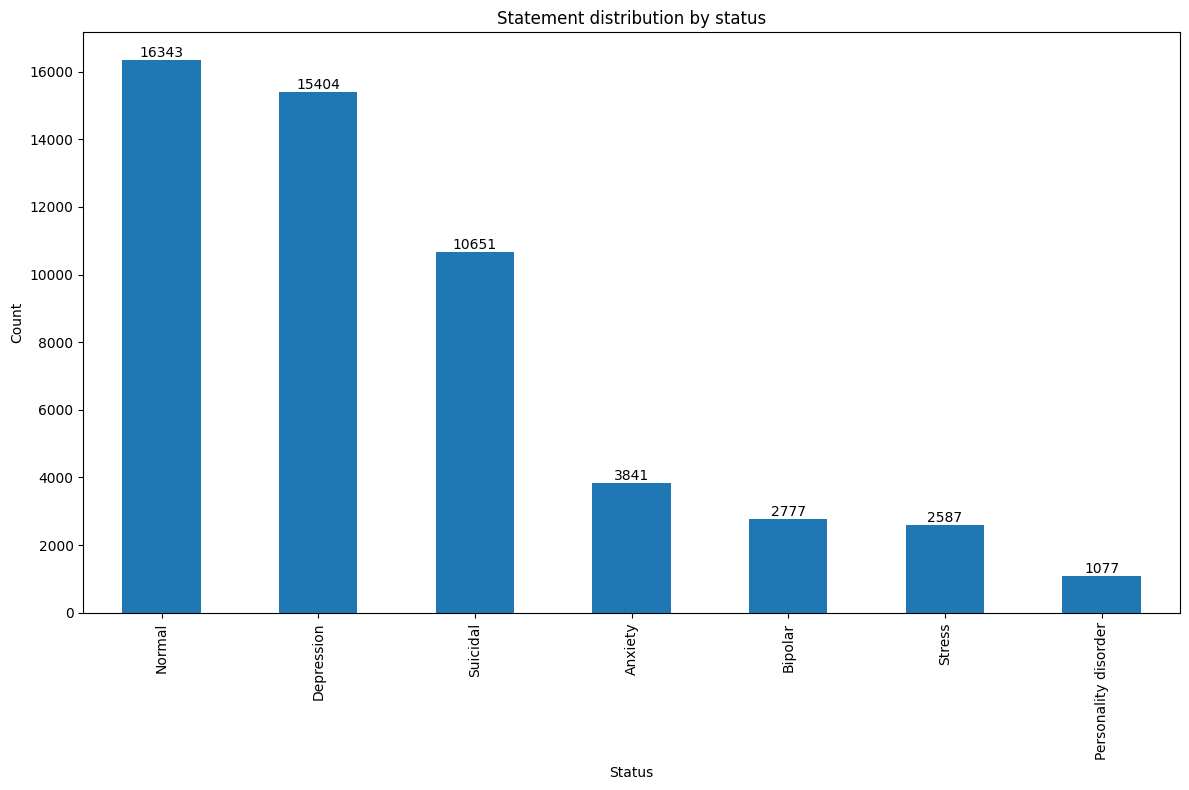

In [ ]:
plt.figure(figsize=(12,8))

# get the unique status values and their counts
status_counts = df1['status'].value_counts()

# create the bar plot
ax = status_counts.plot(kind='bar')

# add the count labels on top of each bar
for i, v in enumerate(status_counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Statement distribution by status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#3.Data Pre-processing

In [ ]:

def clean_text(text):

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove text in square brackets
    text = re.sub(r'\[.*?\]', '', text)

    # Remove URLs (including markdown-style links)
    text = re.sub(r'https?://\S+|www\.\S+|\[.*?\]\(.*?\)', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>+', '', text)

    # Remove handles (that start with '@')
    text = re.sub(r'@\w+', '', text)

    # Remove punctuation and other special characters
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)

    # Remove newline characters
    text = re.sub(r'\n', ' ', text)

    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
df2 = df1.copy()

df2['statement_clean'] = df2['statement'].apply(clean_text)
df2.head()

,Unnamed: 0,statement,status,statement_len,statement_clean
0,0,oh my gosh,Anxiety,3,oh my gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless heart ...
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,all wrong back off dear forward doubt stay in ...
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shifted my focus to something else but im ...
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,im restless and restless its been a month now ...


**Stopwords:**

1. Articles: a, an, the
2. Prepositions: in, on, at, to, for, of, with
3. Pronouns: I, you, he, she, it, we, they, them
4. Conjunctions: and, but, or, so, because
5. Auxiliary verbs: is, am, are, was, were, be, been, have, has, had
6. Common adverbs: very, really, too, also, just
7. Common adjectives: many, much, few, more, most, some, any
8. Others: this, that, these, those, there, here

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

more_stopwords = ['u', 'im', 'c']
stop_words = stopwords.words('english') + more_stopwords

def remove_stopwords(text):
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    return text

df2['statement_clean'] = df2['statement_clean'].apply(remove_stopwords)
df2.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Unnamed: 0,statement,status,statement_len,statement_clean
0,0,oh my gosh,Anxiety,3,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,trouble sleeping confused mind restless heart ...
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shifted focus something else still worried
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,restless restless month boy mean


**Stemming/ Lematization**

Stemming usually refers to a process that chops off the ends of words in the hope of achieving goal correctly most of the time and often includes the removal of derivational affixes.

Lemmatization usually refers to doing things properly with the use of a vocabulary and morphological analysis of words, normally aiming to remove inflectional endings only and to return the base and dictionary form of a word. As far as the meaning of the words is important for this study, we are meant to focus on lemmatization rather than stemming, but for its simplicity we will use stemming.

In [ ]:
stemmer = nltk.SnowballStemmer("english")

def stemm_text(text):
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))
    return text

In [ ]:
df2['statement_clean'] = df2['statement_clean'].apply(stemm_text)
df2.head()

,Unnamed: 0,statement,status,statement_len,statement_clean
0,0,oh my gosh,Anxiety,3,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,troubl sleep confus mind restless heart tune
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shift focus someth els still worri
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,restless restless month boy mean


**All together**

In [ ]:
def preprocess_data(text):

    #Clean puntuation, urls, and so on
    text = clean_text(text)
    # Remove stopwords
    text = ' '.join(word for word in text.split(' ') if word not in stop_words)
    # Stemm all the words in the sentence
    text = ' '.join(stemmer.stem(word) for word in text.split(' '))

    return text

In [ ]:
df2['statement_clean'] = df2['statement_clean'].apply(preprocess_data)
df2.head()

,Unnamed: 0,statement,status,statement_len,statement_clean
0,0,oh my gosh,Anxiety,3,oh gosh
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,troubl sleep confus mind restless heart tune
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shift focus someth el still worri
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,restless restless month boy mean


# Target Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

l_encoder = LabelEncoder()
l_encoder.fit(df2['status'])

df2['status_encoded'] = l_encoder.transform(df2['status'])
df2.head()

,Unnamed: 0,statement,status,statement_len,statement_clean,status_encoded
0,0,oh my gosh,Anxiety,3,oh gosh,0
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety,10,troubl sleep confus mind restless heart tune,0
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,14,wrong back dear forward doubt stay restless re...,0
3,3,I've shifted my focus to something else but I'...,Anxiety,11,ive shift focus someth el still worri,0
4,4,"I'm restless and restless, it's been a month n...",Anxiety,14,restless restless month boy mean,0


# Tokenization

In [ ]:
nltk.download('punkt_tab')
df2['tokens'] = df2['statement_clean'].apply(word_tokenize)
print(df2.head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


  Unnamed: 0                                          statement   status  \
0          0                                         oh my gosh  Anxiety   
1          1  trouble sleeping, confused mind, restless hear...  Anxiety   
2          2  All wrong, back off dear, forward doubt. Stay ...  Anxiety   
3          3  I've shifted my focus to something else but I'...  Anxiety   
4          4  I'm restless and restless, it's been a month n...  Anxiety   

   statement_len                                    statement_clean  \
0              3                                            oh gosh   
1             10       troubl sleep confus mind restless heart tune   
2             14  wrong back dear forward doubt stay restless re...   
3             11              ive shift focus someth el still worri   
4             14                   restless restless month boy mean   

   status_encoded                                             tokens  
0               0                            

In [ ]:
# Get unique categories in 'status'
statuses = df2['status'].unique()

for status in statuses:
    # Filter the tokens data for the current status
    tokens_data = ' '.join(df2[df2['status'] == status]['tokens'].dropna().apply(lambda x: ' '.join(x)).tolist())

print(tokens_data)


anyon interest join group avpd telegram edit telegram group creat invit link number member number member number member creat grouproom peopl avpd want talk peopl avpd break lone pass time make friend lurk plea introduc briefli instanc name age sex countri languag spoken hobbi join group also rememb welcom peopl join group suggest idea improv qualiti group want creat event anyth might improv experi group feel free share group ping avail pc window maco linux iphon io ipad io android phone tablet also web version first need instal one devic use note also speak nativ languag group least one member also speak anyon el noth common peopl see normal peopl constant talk fun genuin shock hell someth talk time know would interest person talk feel like oper lvl social skill everyon el alreadi lvl nobodi around lvl cant even train becom stronger doom lose everi encount ghost would ideal form exist realli enjoy watch peopl live live listen indirect conver public observ event etc problem interf world

# 4.Vectorization

Currently, we have the messages as lists of tokens (also known as lemmas) and now we need to convert each of those messages into a vector the SciKit Learn's algorithm models can work with.

We'll do that in three steps using the bag-of-words model:

1. Count how many times does a word occur in each message (Known as term frequency)
2. Weigh the counts, so that frequent tokens get lower weight (inverse document frequency)
3. Normalize the vectors to unit length, to abstract from the original text length (L2 norm)

In [ ]:
#df2

In [ ]:
# define X and y for use with COUNTVECTORIZER
X = df2['statement_clean']
y = df2['status_encoded']

print(len(X), len(y))

52680 52680


In [ ]:
# Split into train and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 36876
Validation: 7902
Test: 7902


# DTM (Document Term Matrix)

In [ ]:
# instantiate the vectorizer
c_vectorizer = CountVectorizer(stop_words='english', ngram_range=(1,2), max_df=0.7, max_features=50_000)
c_vectorizer.fit(X_train)

CountVectorizer(max_df=0.7, max_features=50000, ngram_range=(1, 2),
                stop_words='english')

In [ ]:
# Use the trained to create a document-term matrix from train and test sets
X_train_dtm = c_vectorizer.transform(X_train)
X_test_dtm = c_vectorizer.transform(X_test)

**TF-IDF (Term Frequency–Inverse Document Frequency)**

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features= 50_000, ngram_range=(1, 2))

tfidf_vectorizer.fit(X_train)
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2194321 stored elements and shape (36876, 50000)>

In [ ]:
texts = df2['statement_clean']
target = df2['status_encoded']

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer

# Calculate the length of our vocabulary
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts(texts)

vocab_length = len(word_tokenizer.word_index) + 1
vocab_length

58120

**Addressing Class Imbalance**

In [ ]:
r_oversampler = RandomOverSampler(random_state= 42)
X_train_resampled, y_train_resampled = r_oversampler.fit_resample(X_train_dtm, y_train)

In [ ]:
r_oversampler = RandomOverSampler(random_state=42)
X_train_resampled2, y_train_resampled2 = r_oversampler.fit_resample(X_train_tfidf, y_train)

In [ ]:
print((X_train_resampled.shape), (y_train_resampled.shape))

(80080, 50000) (80080,)


# 5.Modelling

In [ ]:
lr_clf = LogisticRegression(random_state= 42)

# Train the classifier
lr_clf.fit(X_train_resampled, y_train_resampled)

LogisticRegression(random_state=42)

In [ ]:
y_pred = lr_clf.predict(X_test_dtm)
labels = l_encoder.classes_
conf_matrix = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=labels))

                      precision    recall  f1-score   support

             Anxiety       0.77      0.77      0.77       576
             Bipolar       0.81      0.73      0.77       416
          Depression       0.72      0.67      0.69      2311
              Normal       0.88      0.94      0.91      2452
Personality disorder       0.62      0.62      0.62       162
              Stress       0.62      0.59      0.61       388
            Suicidal       0.63      0.65      0.64      1597

            accuracy                           0.75      7902
           macro avg       0.72      0.71      0.71      7902
        weighted avg       0.75      0.75      0.75      7902



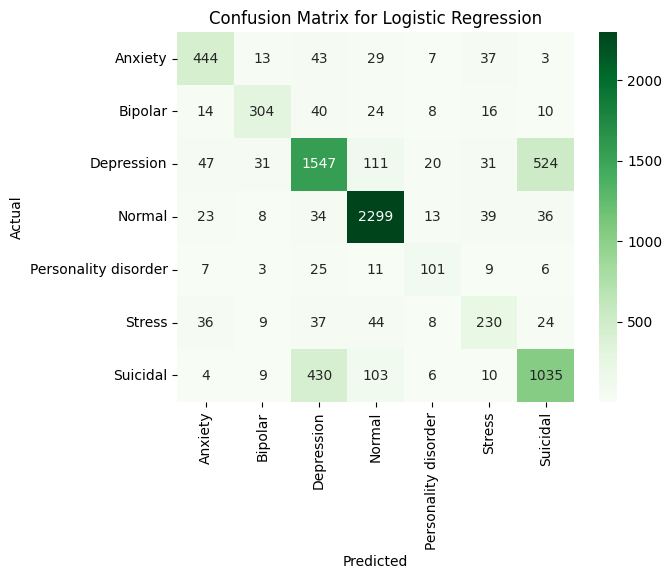

In [ ]:
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100,n_jobs=-1)
rf_clf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred2 = rf_clf.predict(X_test_dtm)
labels = l_encoder.classes_
conf_matrix2 = confusion_matrix(y_test, y_pred2)
print(classification_report(y_test, y_pred2, target_names=labels))

                      precision    recall  f1-score   support

             Anxiety       0.82      0.72      0.77       576
             Bipolar       0.90      0.57      0.70       416
          Depression       0.66      0.72      0.69      2311
              Normal       0.77      0.96      0.85      2452
Personality disorder       0.93      0.35      0.51       162
              Stress       0.88      0.30      0.44       388
            Suicidal       0.67      0.57      0.61      1597

            accuracy                           0.73      7902
           macro avg       0.80      0.60      0.65      7902
        weighted avg       0.73      0.73      0.71      7902



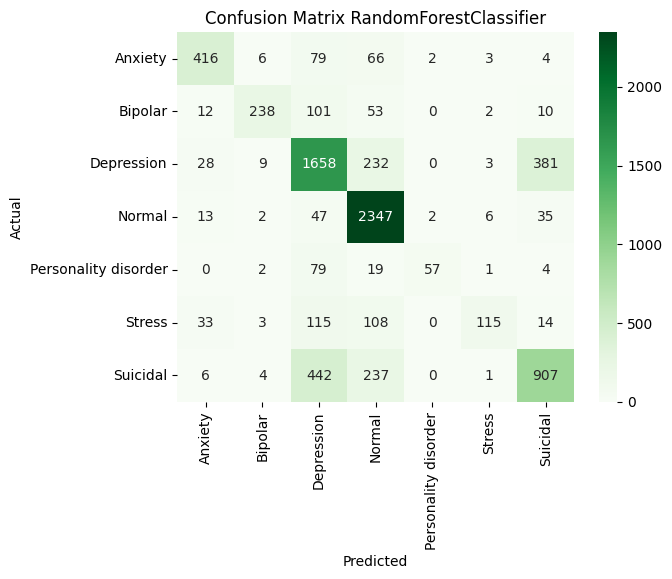

In [ ]:
sns.heatmap(conf_matrix2, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix RandomForestClassifier')
plt.show()

# TF-IDF + LR

In [ ]:
lr_clf_tfidf = LogisticRegression(random_state=42)

lr_clf_tfidf.fit(X_train_resampled2, y_train_resampled2)

y_pred_tfidf = lr_clf_tfidf.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred_tfidf,
    target_names=labels

    ))

                      precision    recall  f1-score   support

             Anxiety       0.79      0.82      0.80       576
             Bipolar       0.80      0.78      0.79       416
          Depression       0.77      0.66      0.71      2311
              Normal       0.88      0.92      0.90      2452
Personality disorder       0.56      0.69      0.62       162
              Stress       0.55      0.64      0.59       388
            Suicidal       0.66      0.70      0.68      1597

            accuracy                           0.77      7902
           macro avg       0.71      0.74      0.73      7902
        weighted avg       0.77      0.77      0.77      7902



# TF-IDF + RF

In [ ]:
rf_clf_tfidf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,n_jobs=-1
)

rf_clf_tfidf.fit(X_train_resampled2, y_train_resampled2)

y_pred2_tfidf = rf_clf_tfidf.predict(X_test_tfidf)

print(classification_report(
    y_test,
    y_pred2_tfidf,
    target_names=labels
))

                      precision    recall  f1-score   support

             Anxiety       0.83      0.68      0.75       576
             Bipolar       0.93      0.55      0.69       416
          Depression       0.63      0.73      0.68      2311
              Normal       0.80      0.95      0.87      2452
Personality disorder       1.00      0.33      0.50       162
              Stress       0.89      0.31      0.46       388
            Suicidal       0.67      0.58      0.62      1597

            accuracy                           0.73      7902
           macro avg       0.82      0.59      0.65      7902
        weighted avg       0.74      0.73      0.72      7902



# BERT (Bidirectional Encoder Representations from Transformers)

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch

# BERT tokenizer
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

# Create validation split from training data
X_train_bert, X_val_bert, y_train_bert, y_val_bert = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

# Tokenization
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Hugging Face datasets
train_ds = Dataset.from_dict({
    "text": X_train_bert.tolist(),
    "labels": y_train_bert.tolist()
})

val_ds = Dataset.from_dict({
    "text": X_val_bert.tolist(),
    "labels": y_val_bert.tolist()
})

test_ds = Dataset.from_dict({
    "text": X_test.tolist(),
    "labels": y_test.tolist()
})

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

# BERT model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(np.unique(y_train))
)

# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Training
training_args = TrainingArguments(
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

# Final evaluation
results = trainer.evaluate(test_ds)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/31344 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.403121,0.657778,3,0.788661,0.790901,0.788661,0.789446


{'eval_loss': 0.6577775478363037, 'eval_accuracy': 0.7886610984560871, 'eval_precision': 0.7909008751250897, 'eval_recall': 0.7886610984560871, 'eval_f1': 0.789446367342927}


In [ ]:
results

{'eval_loss': 0.6577775478363037,
 'eval_accuracy': 0.7886610984560871,
 'eval_precision': 0.7909008751250897,
 'eval_recall': 0.7886610984560871,
 'eval_f1': 0.789446367342927}

In [ ]:
import pandas as pd
import numpy as np

# Textes du test
texts = X_test

# Labels réels et prédits
true_labels = l_encoder.inverse_transform(y_test)
pred_labels = l_encoder.inverse_transform(y_pred_bert)

error_df = pd.DataFrame({
    "Text": texts,
    "True_Label": true_labels,
    "Predicted_Label": pred_labels
})

# Garder uniquement les erreurs
error_df = error_df[
    error_df["True_Label"] != error_df["Predicted_Label"]
].reset_index(drop=True)

print("Nombre d'erreurs :", len(error_df))
print("Taux d'erreur :", round(len(error_df) / len(texts), 4))

error_df.head(20)

Nombre d'erreurs : 1670
Taux d'erreur : 0.2113


,Text,True_Label,Predicted_Label
0,one hugh eastern standard definit one ill plan...,Normal,Suicidal
1,need feel someth pure miseri anger ever sinc g...,Suicidal,Depression
2,day eat bite got made sandwich earlier today k...,Depression,Normal
3,buy pain pill onlin legit genuin site prescrip...,Anxiety,Suicidal
4,feel empti felt love even ex felt alon empti n...,Suicidal,Depression
5,step right direct job interview come thursday ...,Bipolar,Normal
6,play colleg soccer accomplish everyth el fail ...,Suicidal,Normal
7,kid verbal emot abus alway scare scream confro...,Depression,Suicidal
8,mani beer kill lol get drunk,Suicidal,Normal
9,final decid move go low contact contact narcis...,Depression,Suicidal


In [ ]:
confusion_errors = (
    error_df
    .groupby(["True_Label", "Predicted_Label"])
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

print(confusion_errors)

              True_Label       Predicted_Label  Count
17            Depression              Suicidal    477
38              Suicidal            Depression    365
22                Normal                Stress     71
14            Depression                Normal     58
39              Suicidal                Normal     57
20                Normal            Depression     53
23                Normal              Suicidal     51
32                Stress            Depression     37
1                Anxiety            Depression     37
30                Stress               Anxiety     37
33                Stress                Normal     35
7                Bipolar            Depression     33
16            Depression                Stress     32
26  Personality disorder            Depression     29
12            Depression               Anxiety     29
4                Anxiety                Stress     29
13            Depression               Bipolar     23
15            Depression  Pe

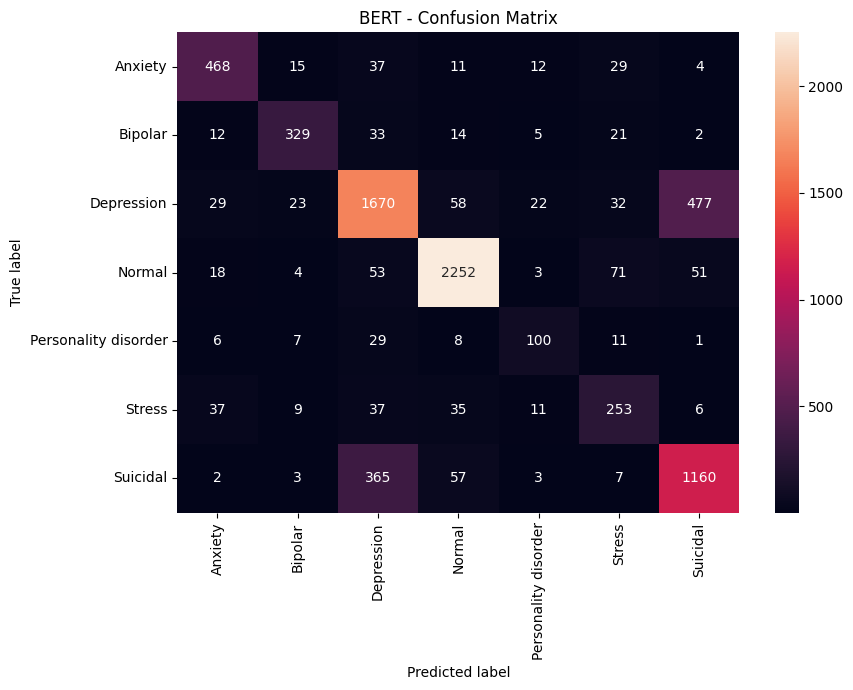

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=l_encoder.classes_,
    yticklabels=l_encoder.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("BERT - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6.Results

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions des 4 modèles classiques
# y_pred       = DTM + Logistic Regression
# y_pred2      = DTM + Random Forest
# y_pred_tfidf = TF-IDF + Logistic Regression
# y_pred2_tfidf = TF-IDF + Random Forest

# Prediction BERT
predictions = trainer.predict(test_ds)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

results = []

models = [
    ("Logistic Regression", "DTM", y_test, y_pred),
    ("Random Forest", "DTM", y_test, y_pred2),
    ("Logistic Regression", "TF-IDF", y_test, y_pred_tfidf),
    ("Random Forest", "TF-IDF", y_test, y_pred2_tfidf),
    ("BERT", "Contextual", y_test, y_pred_bert)
]

for model, representation, y_true, y_pred_model in models:
    results.append({
        "Model": model,
        "Representation": representation,
        "Accuracy": accuracy_score(y_true, y_pred_model),
        "Precision": precision_score(y_true, y_pred_model, average="macro"),
        "Recall": recall_score(y_true, y_pred_model, average="macro"),
        "F1": f1_score(y_true, y_pred_model, average="macro")
    })

results_df = pd.DataFrame(results)

# Arrondir
results_df[["Accuracy", "Precision", "Recall", "F1"]] = \
    results_df[["Accuracy", "Precision", "Recall", "F1"]].round(4)

print(results_df)

                 Model Representation  Accuracy  Precision  Recall      F1
0  Logistic Regression            DTM    0.7542     0.7204  0.7104  0.7148
1        Random Forest            DTM    0.7261     0.8037  0.5979  0.6534
2  Logistic Regression         TF-IDF    0.7660     0.7141  0.7440  0.7270
3        Random Forest         TF-IDF    0.7267     0.8211  0.5907  0.6516
4                 BERT     Contextual    0.7887     0.7510  0.7486  0.7493


# 7.Analyse d'erreurs

In [ ]:
def get_errors(texts, y_true, y_pred, model_name):
    true_labels = l_encoder.inverse_transform(y_true)
    pred_labels = l_encoder.inverse_transform(y_pred)

    df = pd.DataFrame({
        "Text": texts,
        "True": true_labels,
        "Predicted": pred_labels
    })

    df = df[df["True"] != df["Predicted"]].copy()
    df["Model"] = model_name

    return df


errors_lr_dtm = get_errors(
    X_test, y_test, y_pred, "LR + DTM"
)

errors_rf_dtm = get_errors(
    X_test, y_test, y_pred2, "RF + DTM"
)

errors_lr_tfidf = get_errors(
    X_test, y_test, y_pred_tfidf, "LR + TF-IDF"
)

errors_rf_tfidf = get_errors(
    X_test, y_test, y_pred2_tfidf, "RF + TF-IDF"
)

errors_bert = get_errors(
    X_test, y_test, y_pred_bert, "BERT"
)

all_errors = pd.concat([
    errors_lr_dtm,
    errors_rf_dtm,
    errors_lr_tfidf,
    errors_rf_tfidf,
    errors_bert
])

print(all_errors.head(20))

                                                    Text        True  \
15960  realli feel fine enough feel like someth screa...  Depression   
12515  need feel someth pure miseri anger ever sinc g...    Suicidal   
20397  day eat bite got made sandwich earlier today k...  Depression   
34672  buy pain pill onlin legit genuin site prescrip...     Anxiety   
17776  everyon around sen stabil develop routin hope ...  Depression   
23267  want take drug feel happi want feel noth pain ...  Depression   
15521  find funni everyon alway tell need hello reach...    Suicidal   
46319  step right direct job interview come thursday ...     Bipolar   
13292  play colleg soccer accomplish everyth el fail ...    Suicidal   
22596  kid verbal emot abus alway scare scream confro...  Depression   
14685                       mani beer kill lol get drunk    Suicidal   
20997  final decid move go low contact contact narcis...  Depression   
19475  hi guy research univ canberra australia intere...  Depres

In [ ]:
error_summary = (
    all_errors
    .groupby("Model")
    .size()
    .reset_index(name="Number_of_Errors")
)

print(error_summary)

         Model  Number_of_Errors
0         BERT              1670
1     LR + DTM              1942
2  LR + TF-IDF              1849
3     RF + DTM              2164
4  RF + TF-IDF              2160


# 8.Analyse critique
BERT obtient les meilleures performances globales, avec une Accuracy de 78,87 % et un F1-score de 74,93 %. Parmi les modèles classiques, Logistic Regression avec TF-IDF présente les meilleurs résultats, avec une Accuracy de 76,60 % et un F1-score de 72,70 %.
Random Forest possède une Precision élevée, mais un Recall plus faible, ce qui montre qu'il ne détecte pas aussi bien les différentes classes. Les résultats suggèrent que les représentations contextuelles de BERT apportent une amélioration par rapport aux approches classiques sur ce jeu de données.

# 9.Limites
- Le déséquilibre des classes peut influencer les performances des modèles.
- Les résultats dépendent de la qualité et de la diversité du dataset.
- Certains textes sont ambigus et peuvent être difficiles à classifier.
- BERT est plus coûteux en temps de calcul et plus difficile à interpréter.
- Les prédictions ne peuvent pas être considérées comme des diagnostics médicaux.
# 10.Perspectives
- Optimiser les hyperparamètres des modèles.
- Tester d'autres modèles pré-entraînés comme RoBERTa ou DistilBERT.
- Comparer le Random Oversampling avec les poids de classes.
- Utiliser SHAP ou LIME pour améliorer l'interprétabilité.
- Tester les modèles sur un autre dataset pour évaluer leur capacité de généralisation.

# 11.Conclusion
Ce projet a permis de comparer quatre modèles classiques et un modèle BERT pour la classification de textes liés à la santé mentale. BERT obtient le meilleur F1-score macro (74,93 %), suivi de Logistic Regression avec TF-IDF (72,70 %). Les résultats montrent l'intérêt des représentations contextuelles pour cette tâche, tout en soulignant l'importance de la qualité des données et de l'analyse des erreurs. Des améliorations restent possibles, notamment au niveau de l'optimisation des modèles, de l'interprétabilité et de la généralisation.

#Références
1. Demszky et al. (2020) — GoEmotions: A Dataset of Fine-Grained Emotions.
2. Liu et al. (2022) — Detecting and Measuring Depression on Social Media Using a Machine Learning Approach.
3. He et al. (2026) — Mental Health Risk Detection From Social Media Text Data: A Scoping Review.
4. Machine Learning and Natural Language Processing in Mental Health: Systematic Review (2021).
5. Dataset Kaggle "https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health"